# Имя: Деджуи Мбоссье борис Франк
# Гр: 925-М
# Вариант №2: Boston Housing (legacy)




## Задание 1: Анализ кривых обучения и переобучения

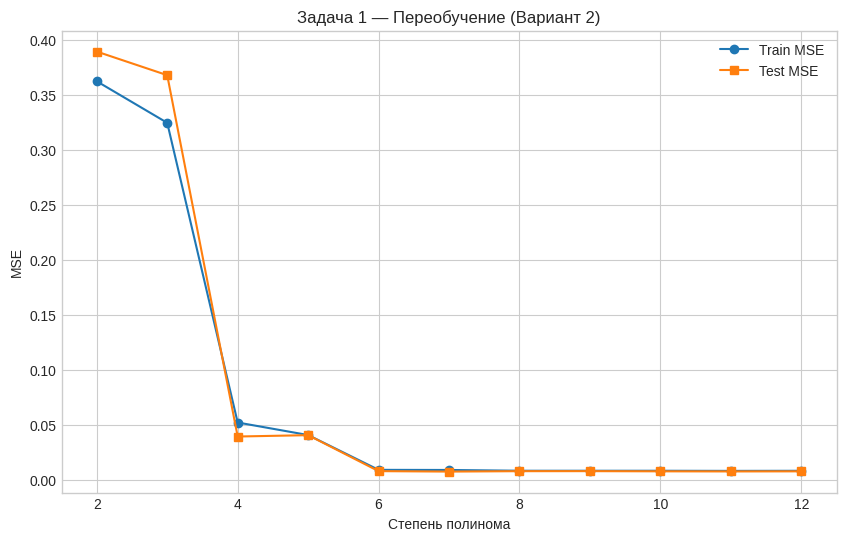

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Génération des données : sin(x) + bruit
X = np.linspace(0, 10, 150).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Séparation train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Listes pour stocker les erreurs
train_mse = []
test_mse = []

# Degrés du polynôme (variant 2)
degrees = range(2, 13)

# Boucle sur les degrés
for d in degrees:
    model = make_pipeline(
        PolynomialFeatures(d, include_bias=False),
        LinearRegression()
    )
    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, pred_train))
    test_mse.append(mean_squared_error(y_test, pred_test))

# Affichage du graphique
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse, marker='o', label='Train MSE')
plt.plot(degrees, test_mse, marker='s', label='Test MSE')
plt.xlabel("Степень полинома")
plt.ylabel("MSE")
plt.title("Задача 1 — Переобучение (Вариант 2)")
plt.legend()
plt.show()


#Результаты
На графике видно, что ошибка на обучающей выборке уменьшается, когда степень полинома становится больше. Это значит, что модель всё лучше запоминает данные. Ошибка на тестовой выборке сначала уменьшается, но после определённой степени начинает расти. Такая форма графика показывает момент, когда модель становится слишком сложной и начинает переобучаться. Разница между ошибками train и test хорошо показывает этот эффект.

#Выводы
При маленьких степенях модель плохо описывает данные — это недообучение. При больших степенях модель слишком точно подстраивается под обучающие данные и теряет качество на тесте — это переобучение. Оптимальная степень находится там, где ошибка на тесте минимальна и разрыв между train и test небольшой.


## Задание 2:  Сравнение регуляризаторов L1 и L2

In [ ]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import RidgeCV, LassoCV

np.random.seed(42)

# Génération d'un dataset avec 15 features
X_reg, y_reg = make_regression(
    n_samples=200,
    n_features=15,
    n_informative=5,
    noise=10,
    random_state=42
)

# Диапазон alpha (Вариант 2 : logspace(-2, 4))
alphas = np.logspace(-2, 4, 50)

# RidgeCV et LassoCV
ridge_cv = RidgeCV(alphas=alphas, cv=5)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)

ridge_cv.fit(X_reg, y_reg)
lasso_cv.fit(X_reg, y_reg)

print("Лучший alpha Ridge :", ridge_cv.alpha_)
print("Лучший alpha Lasso :", lasso_cv.alpha_)

print("Ненулевых коэффициентов Ridge :", np.sum(ridge_cv.coef_ != 0))
print("Ненулевых коэффициентов Lasso :", np.sum(lasso_cv.coef_ != 0))


Лучший alpha Ridge : 0.01
Лучший alpha Lasso : 0.6866488450043002
Ненулевых коэффициентов Ridge : 15
Ненулевых коэффициентов Lasso : 5


#Результаты
После выполнения кросс‑валидации модель Ridge выбрала значение параметра α = 0.01. Это очень маленькое значение, поэтому регуляризация почти не влияет на веса, и модель сохраняет все 15 коэффициентов ненулевыми. Это показывает, что Ridge сглаживает веса, но не удаляет признаки.

Для модели Lasso оптимальное значение α оказалось больше — примерно 0.6866. При таком значении регуляризация L1 становится сильнее, и модель занулила часть коэффициентов. В результате у Lasso осталось только 5 ненулевых признаков. Это означает, что Lasso автоматически выбрал только те признаки, которые наиболее важны для предсказания.

#Выводы
Результаты показывают, что Ridge и Lasso работают по‑разному. Ridge почти не уменьшает количество признаков и оставляет все коэффициенты ненулевыми, даже при регуляризации. Модель Lasso, наоборот, удаляет неважные признаки и делает модель более простой. В нашем случае Lasso выбрал только 5 признаков из 15, что подтверждает его способность выполнять отбор признаков. Поэтому Lasso лучше подходит, когда нужно уменьшить размерность данных и оставить только самые важные переменные.

Задание 3: Отбор признаков на реальных данных

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Загрузка датасета California Housing
data = fetch_california_housing()
X_real = data.data
y_real = data.target
feature_names = data.feature_names

# Отбор K=6 признаков (Вариант 2)
selector = SelectKBest(score_func=f_regression, k=6)
X_kbest = selector.fit_transform(X_real, y_real)

# Correction ici :
selected = np.array(feature_names)[selector.get_support()]
print("Выбранные признаки (K=6) :", selected)

# Модель на всех признаках
model_full = LinearRegression()
model_full.fit(X_real, y_real)
r2_full = r2_score(y_real, model_full.predict(X_real))

# Модель только на отобранных признаках
model_k = LinearRegression()
model_k.fit(X_kbest, y_real)
r2_k = r2_score(y_real, model_k.predict(X_kbest))

print("R2 полной модели :", r2_full)
print("R2 модели с K=6 :", r2_k)


Выбранные признаки (K=6) : ['MedInc' 'HouseAge' 'AveRooms' 'AveBedrms' 'Latitude' 'Longitude']
R2 полной модели : 0.606232685199805
R2 модели с K=6 : 0.6050397785905599


#Результаты
После применения метода SelectKBest были выбраны шесть признаков: MedInc, HouseAge, AveRooms, AveBedrms, Latitude и Longitude. Эти признаки показали наибольшую статистическую связь с целевой переменной. Затем были обучены две модели: первая — на всех признаках, вторая — только на выбранных шести. Значение R² для полной модели составило 0.6062, а для модели с K=6 — 0.6050. Разница между ними очень маленькая, что показывает, что выбранные признаки содержат почти всю важную информацию для предсказания.
#Выводы
Отбор шести признаков практически не ухудшил качество модели: значение R² осталось почти таким же, как у полной модели. Это означает, что часть исходных признаков была менее полезной, и модель может работать эффективно даже с меньшим набором данных. Модель с K=6 становится проще, легче для интерпретации и быстрее обучается, сохраняя при этом хорошую точность. Такой результат подтверждает пользу методов отбора признаков в задачах машинного обучения.

#Общий вывод по варианту
В ходе выполнения всех трёх заданий мы увидели, как разные методы помогают контролировать сложность модели и улучшать её качество. В первом задании мы изучили влияние степени полинома и увидели, что слишком сложная модель начинает переобучаться: ошибка на обучении становится маленькой, но ошибка на тесте растёт. Во втором задании мы сравнили регуляризаторы Ridge и Lasso. Ridge почти не уменьшает число признаков, а Lasso, наоборот, зануляет лишние коэффициенты и оставляет только самые важные. В третьем задании мы применили отбор признаков на реальных данных и получили, что модель с шестью признаками показывает почти такое же качество, как и полная модель. Это подтверждает, что правильный выбор признаков и контроль сложности помогают строить более простые, устойчивые и понятные модели машинного обучения.